# The art of using t-SNE for single-cell transcriptomics. Tutorial. 
This repository is based on the original rna-seq-tsne project by the Berens Lab. The additional experiments and notes in this fork are my own.  

### ADDED: I have added descriptive text and thoughts to the original `demo.ipynb file`, as well as study goals, to this file. All experiments in terms of code changes and additional output are in separate files.  

This tutorial uses the data set from https://www.nature.com/articles/s41586-018-0654-5.

This notebook is self-contained. All functions that one needs to run this notebook are defined below.

Please install FIt-SNE from https://github.com/KlugerLab/FIt-SNE.

In [7]:
# Prepare

#%matplotlib notebook - removed as prevented plotting!
%matplotlib inline

import numpy as np
import pylab as plt
import seaborn as sns; sns.set_theme()
import pandas as pd
import pickle
import scipy
import matplotlib
from scipy import sparse
import sklearn
from sklearn.decomposition import PCA
from sklearn.manifold import MDS

In [8]:
# import tsne
import os
import sys
sys.path.append(os.path.expanduser('~/FIt-SNE'))
from fast_tsne import fast_tsne

In [11]:
print('Python version', sys.version)
print('Numpy', np.__version__)
print('Matplotlib', matplotlib.__version__)
print('Seaborn', sns.__version__)
print('Pandas', pd.__version__)
print('Scipy', scipy.__version__)
print('Sklearn', sklearn.__version__)

Python version 3.11.14 (main, Oct 21 2025, 18:27:30) [Clang 20.1.8 ]
Numpy 1.26.4
Matplotlib 3.8.0
Seaborn 0.12.2
Pandas 2.1.4
Scipy 1.11.4
Sklearn 1.2.2


## Load the data
Download the data from here: http://celltypes.brain-map.org/rnaseq and unpack. Direct links:
 * VISp: http://celltypes.brain-map.org/api/v2/well_known_file_download/694413985
 * ALM: http://celltypes.brain-map.org/api/v2/well_known_file_download/694413179

To get the information about cluster colors and labels (`sample_heatmap_plot_data.csv`), open the interactive data browser http://celltypes.brain-map.org/rnaseq/mouse/v1-alm, go to "Sample Heatmaps", click "Build Plot!" and then "Download data as CSV". For later reproducibility, this file is also provided in this github repository (`data` folder).

## Data download notes
The data files contain RNA sequencing data of single cells isolated from either the mouse primary visual cortex (VISp) or anterior lateral motor cortical area (ALM). For both, sequencing results were aligned either to exons or introns in the GRCm38.p3 reference genome using the STAR algorithm, and aggregated counts at the gene level were calculated. I this tutorial we are using read counts obtained for each (gene, sample) pair based on alignment to **exons**. Row 1 (python index 0) contains the unique identifiers of the samples (cells) and column 1 (python index 0) contains the unique identifiers of the genes.

### SciPy API update  
The sparseload function is used to read data from two large datasets in chunks (of 1000). It returns the gene count, gene ID, cell ID, and brain area (`counts, genes, cells, areas`). The function uses the scipy.sparse module which contains functions to deal with sparse data. Sparse data is data that has mostly unused elements (elements that don't carry any information, e.g. when there are a lot of 0 values). In the original function sparse blocks were created by using the sparse.csr_matrix() function, however from version 1.18.0 SciPy sparse is shifting from a sparse matrix interface to a sparse array interface. Therefore **I will aim to adjust the code to be array compliant** as per the instructions here: [https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html#migration-to-sparray](https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html#migration-to-sparray), bearing in mind that downstream calculations might expect a sparse matrix and not an array.  

### sparseload function  
The function creates 4 empty lists to receive data relating to genes, sparseblocks, areas, and cells. Data is read from two separate .CSV files, as specified by the user, in chunks of 1000, where the data from the first file is referred to as chunk1, and the data from the second file is referred to as chunk2. When the function is first called the cells list will be empty (i.e. `len(cells) == 0` will be `True`) and therefore `cells` will be assigned the output created by joining (concatenating) the column names of chunk1 and chunk2 as a NumPy array. In addition, the areas list is filled with zeros and ones, the number of which is equal to the number of columns in file 1 (in former case) and number of columns in file 2 (in latter case). So the two brain areas are coded as: `primary visual cortex (VISp) = 0` and `anterior lateral motor cortical area (ALM) = 1`. All subsequent iterations of the for loop will skil this step (as `len(cells)==0` will be `False`.  

For every subsequent chunk of 1000 rows, the gene names in the indices of the specific row is added to the `genes` list. After that, the values in each chunk is converted to a sparse array (only the non-zero values and their positions are stored), and the chunks from the two different files are stacked horizontally (equivalent to cbind() in R). Finally these stacked sparse blocks are added to the `sparseblocks` list.  

The line `print('.', end='', flush=True)` causes a dot to be printed to screen every time a (chunk1, chunk2) pair passes through the `for` loop.  

When all chunks are read, the sparseblocks created from them are converted into a count matrix for downstream applications. The function then returns the counts (as an inverse matrix), the gene names as a NumPy array, the cell IDs (a list), and the brain areas (either 0 or 1) as a NumPy array.  

**Note:** It appears that the data is cleaned up by applying input from a previous analysis ("tasic-sample_heatmap_plot_data.csv"). 

In [9]:
%%time

# Load the Allen institute data. This takes a few minutes

# This function is needed because using Pandas to load these files in one go 
# can eat up a lot of RAM. So we are doing it in chunks, and converting each
# chunk to the sparse matrix format on the fly.
def sparseload(filenames):
    genes = []
    sparseblocks = []
    areas = []
    cells = []
    for chunk1,chunk2 in zip(pd.read_csv(filenames[0], chunksize=1000, index_col=0, na_filter=False),
                             pd.read_csv(filenames[1], chunksize=1000, index_col=0, na_filter=False)):
        if len(cells)==0:
            cells = np.concatenate((chunk1.columns, chunk2.columns))
            areas = [0]*chunk1.columns.size + [1]*chunk2.columns.size
        
        genes.extend(list(chunk1.index))
        sparseblock1 = sparse.csr_array(chunk1.values.astype(float))
        sparseblock2 = sparse.csr_array(chunk2.values.astype(float))
        sparseblock = sparse.hstack((sparseblock1,sparseblock2), format='csr')
        sparseblocks.append([sparseblock])
        print('.', end='', flush=True)
    print(' done')
    counts = sparse.bmat(sparseblocks)
    return (counts.T, np.array(genes), cells, np.array(areas))

filenames = ['data/mouse_VISp_gene_expression_matrices_2018-06-14/mouse_VISp_2018-06-14_exon-matrix.csv',
             'data/mouse_ALM_gene_expression_matrices_2018-06-14/mouse_ALM_2018-06-14_exon-matrix.csv']
counts, genes, cells, areas = sparseload(filenames)

# read file with cols: gene_symbol, gene_id, chromosome, gene_entrez_id, gene_name
# create dictionary with gene_id keys and gene_symbol values
# look up value associated with gene_id as stored in `genes` list, and swap with gene_symbol
genesDF = pd.read_csv('data/mouse_VISp_gene_expression_matrices_2018-06-14/mouse_VISp_2018-06-14_genes-rows.csv')
ids     = genesDF['gene_entrez_id'].tolist()
symbols = genesDF['gene_symbol'].tolist()
id2symbol = dict(zip(ids, symbols))
genes = np.array([id2symbol[g] for g in genes])

# read cluster info and convert columns to NumPy arrays
clusterInfo = pd.read_csv('data/tasic-sample_heatmap_plot_data.csv')
goodCells  = clusterInfo['sample_name'].values
ids        = clusterInfo['cluster_id'].values
labels     = clusterInfo['cluster_label'].values
colors     = clusterInfo['cluster_color'].values

# get cluster labels and colours
clusterNames  = np.array([labels[ids==i+1][0] for i in range(np.max(ids))])
clusterColors = np.array([colors[ids==i+1][0] for i in range(np.max(ids))])
clusters   = np.copy(ids) - 1

# find rows with "good" cells and package everything into a dictionary that contains objects (e.g. gene count matrix) to be used downstream
ind = np.array([np.where(cells==c)[0][0] for c in goodCells])
counts = counts[ind, :]

tasic2018 = {'counts': counts, 'genes': genes, 'clusters': clusters, 'areas': areas, 
             'clusterColors': clusterColors, 'clusterNames': clusterNames}
counts = []

.............................................. done
CPU times: user 1min, sys: 7.35 s, total: 1min 7s
Wall time: 1min 7s


In [11]:
print('Number of cells:', tasic2018['counts'].shape[0])
print('Number of cells from ALM:', np.sum(tasic2018['areas']==0))
print('Number of cells from VISp:', np.sum(tasic2018['areas']==1))
print('Number of clusters:', np.unique(tasic2018['clusters']).size)
print('Number of genes:', tasic2018['counts'].shape[1])
print('Fraction of zeros in the data matrix: {:.2f}'.format(
    tasic2018['counts'].size/np.prod(tasic2018['counts'].shape)))

Number of cells: 23822
Number of cells from ALM: 15413
Number of cells from VISp: 10068
Number of clusters: 133
Number of genes: 45768
Fraction of zeros in the data matrix: 0.20


## Pre-processing

The data set consists of thousands of cells, each of which has expression data for thousands of genes. One of the challenges in big data analysis is the large number of features (dimensions) which can cause computational issues. Here the authors have done feature selection by calculating the mean expression of a gene among cells where it is detected, as well as the proportion of cells where the gene is near-zero, setting a threshold on both and selecting only the top 3000 genes that have unusally high detection frequency relative to expression level. The plot shows that a lot of genes will be filtered out through feature selection (selectedGenes creates a Boolean mask to apply to our data set). 

In [14]:
%%time

# Feature selection

# function that identifies proportion of cells in which the gene has expression =< threshold
def nearZeroRate(data, threshold=0):
    zeroRate = 1 - np.squeeze(np.array((data>threshold).mean(axis=0)))
    return zeroRate

# function that calculates the mean log expression of a gene among the cells where that gene is detected above a set threshold
# default setting: the gene needs to be detected in at least 10 cells
def meanLogExpression(data, threshold=0, atleast=10):
    nonZeros = np.squeeze(np.array((data>threshold).sum(axis=0)))
    N = data.shape[0]
    A = data.multiply(data>threshold)
    A.data = np.log2(A.data)
    meanExpr = np.zeros(data.shape[1]) * np.nan
    detected = nonZeros >= atleast
    meanExpr[detected] = np.squeeze(np.array(A[:,detected].mean(axis=0))) / (nonZeros[detected]/N)
    return meanExpr

# find N number of genes that have unusually high variability relative to their expression level
def featureSelection(meanLogExpression, nearZeroRate, yoffset=.02, decay=1.5, n=3000):
    low = 0; up=10    
    nonan = ~np.isnan(meanLogExpression)
    xoffset = 5
    for step in range(100):
        selected = np.zeros_like(nearZeroRate).astype(bool)
        selected[nonan] = nearZeroRate[nonan] > np.exp(-decay*meanLogExpression[nonan] + xoffset) + yoffset
        if np.sum(selected) == n:
            break
        elif np.sum(selected) < n:
            up = xoffset
            xoffset = (xoffset + low)/2
        else:
            low = xoffset
            xoffset = (xoffset + up)/2
    return selected

x = meanLogExpression(tasic2018['counts'], threshold=32)  # Get mean log non-zero expression of each gene from expression matrix 
y = nearZeroRate(tasic2018['counts'], threshold=32)       # Get near-zero frequency of each gene from expression matrix
selectedGenes = featureSelection(x, y, n=3000)            # Adjust the threshold to select 3000 genes

CPU times: user 6.75 s, sys: 3.88 s, total: 10.6 s
Wall time: 11.4 s


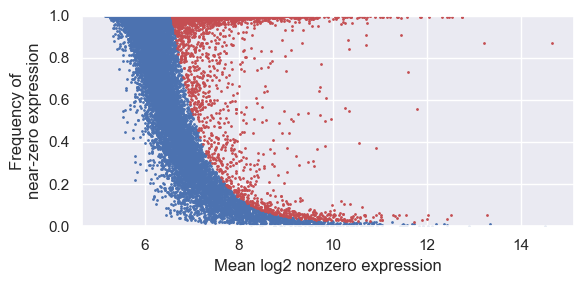

In [16]:
# Plot  
# Genes NOT selected for further analysis are in blue
# Genes selected for further analysis are in red; these genes have a high expression level (above threshold) when detected
# AND unusually high near-zero frequency
plt.figure(figsize=(6,3))
plt.scatter(x[~selectedGenes], y[~selectedGenes], s=1)
plt.scatter(x[selectedGenes],  y[selectedGenes], s=1, color='r')
plt.xlabel('Mean log2 nonzero expression')
plt.ylabel('Frequency of\nnear-zero expression')
plt.ylim([0,1])
plt.tight_layout()

## PCA  

### What is happening?  
The original expression matrix has many dimensions because each gene is a feature (see stats in previous blocks: 10 000 - 15 000 cells, and over 45 000 genes). Principal Component Analysis (PCA) combines different proportions of the features to produce principle components that capture maximal variance, so that the first principle component explains the most variance and each subsequent principal component explains less variance. There are as many principle components as there are features, although often a subset is kept. PCA is a dimensionality reduction method that maintains the structure of the data so that we can interpret it.  

Here the authors reduce the data to 50 dimensions before applying t-SNE.  

### Things I want to understand  
- Why 50 PCs?
- How much variance is retained?
- What does each PC represent?
- What happens if I use 10 PCs?
- What happens if I use 100 PCs?

Output for these questions are in file [02_pca_experiments.ipynb](https://github.com/PlantsGenesBugs/rna-seq-tsne-practice/blob/my-practice/02_pca_experiments.ipynb)

In [65]:
%%time
# select genes according to selectedGenes mask
# normalise gene counts and log transform
# perform dimensionality reduction using PCA

counts3k = tasic2018['counts'][:, selectedGenes]    # Feature selection

librarySizes = np.asarray(
    tasic2018['counts'].sum(axis=1)
).ravel()                                           # Compute library sizes

CPM = counts3k.toarray() / librarySizes[:, None] * 1e6    # Library size normalisation; convert to dense for PCA

logCPM = np.log2(CPM + 1)                                 # Log-transformation - integer counts don't work well with subsequent methods

pca = PCA(n_components=50, svd_solver='full').fit(logCPM)   # PCA; determine first 50 PCs loadings and sizes

flipSigns = np.sum(pca.components_, axis=1) < 0             # fix PC signs; identify PCs where the sum of loadings < 0 (Boolean mask)
X = pca.transform(logCPM)                                   # apply PC loadings and sizes to data
X[:, flipSigns] *= -1                                       # if the PC has been identified as summing to <0, multiply the loadings for each gene by -1
                                                            # Flipping the sign imposes a convention so that our PCs have a consistent direction even if the analysis is re-run

print('Shape of the resulting matrix:', X.shape, '\n')

Shape of the resulting matrix: (23822, 50) 

CPU times: user 3min 58s, sys: 10.3 s, total: 4min 8s
Wall time: 36.4 s


## Initial data exploration (PCA/MDS)  
The output of the PCA function above is a matrix consisting of the scores (coordinates) of the first 50 PCs of the PCA (in columns) and the cells used in the analysis in the rows. In the first instance we look at a graph comparing PC1 and PC2. These represent linear combinations of the genes that capture the greatest (PC1) and second-greatest (PC2) variance in the data set. The cells are coloured by previously identified clusters. 

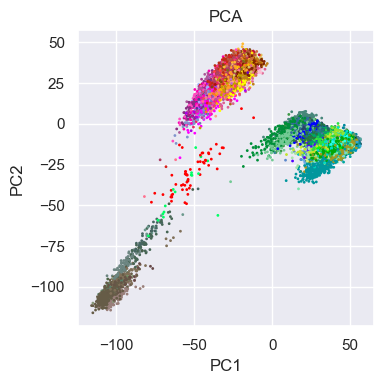

In [73]:
# Principal component analysis

plt.figure(figsize=(4,4))
plt.scatter(X[:,0], X[:,1], s=1, color=tasic2018['clusterColors'][tasic2018['clusters']])
plt.title('PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()

There appear to be three distinct clusters of cells when looking at PC1 and PC2. Below we take a closer look at the cluster in the lower, left-hand quadrant, i.e. cells that have a PC1 and PC2 value lower than -50. We will select all cells that fall within this threshold and do a secondary PCA where we find the two directions of greatest variation across the existing 50-dimensional representation. 

The first PCA was performed on all cells and captured the strongest sources of variation across the entire dataset. These sources may be things like broad cell-type differences. The second PCA is done to describe variation within a subset of the cells (the original PCs may not be optimal to describe more local variation). Here we can already see that something like t-SNE which is better at preserving local data structure.

CPU times: user 365 ms, sys: 6.36 ms, total: 371 ms
Wall time: 69.3 ms


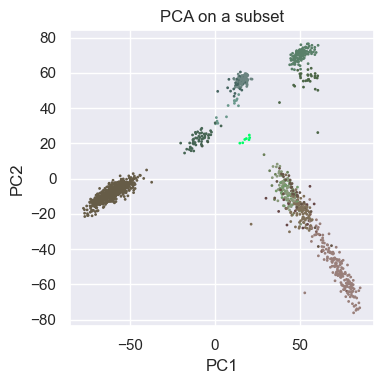

In [81]:
%%time

# PCA on a subset identified in the previous figure

subset = (X[:,0] < -50) & (X[:,1] < -50)                   # select genes where PC1 < -50 and PC2 < -50
Xsubset = PCA(n_components=2).fit_transform(X[subset,:])   # apply PCA and return top 2 components

plt.figure(figsize=(4,4))
plt.scatter(Xsubset[:,0], Xsubset[:,1], s=1, 
            color=tasic2018['clusterColors'][tasic2018['clusters'][subset]])
plt.title('PCA on a subset')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()

Secondary PCA on one cluster has revealed clear sub-clusters within it.

### Compare cluster-level averages  
Instead of analysing individual cells, collapse cells into cluster-level averages and explore how different clusters compare to each other in expression space.

/opt/anaconda3/lib/python3.11/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


CPU times: user 2.55 s, sys: 336 ms, total: 2.89 s
Wall time: 419 ms


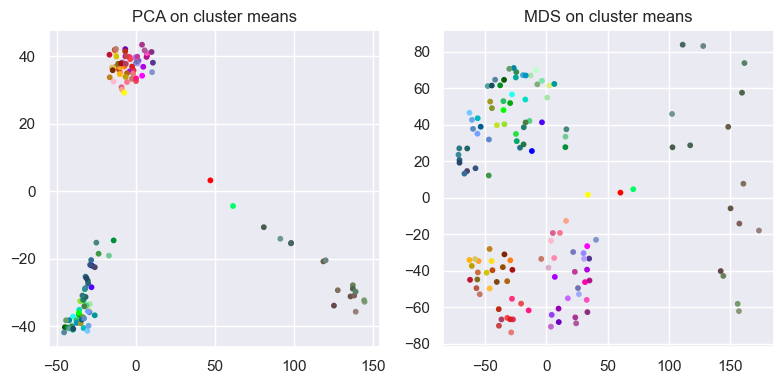

In [84]:
%%time

# If clustering results are available, do PCA and/or MDS on the cluster means

# count number of unique clusters 
C = np.unique(tasic2018['clusters']).size                   

# calculate the mean value (coordinate) for each PC, for each cluster - the centroid of the cluster in 50-dimensional PCA space
clusterMeans = np.zeros((C, X.shape[1]))
for c in range(C):
    clusterMeans[c,:] = np.mean(X[tasic2018['clusters']==c,:], axis=0)

# perform PCA on these cluster means (matrix contains clusters in rows and mean PC values for PC1... PC50 in columns)
# also perform multi-dimensional scaling: 2D representation of data where distances between observations are preserved
# each point in the output represents a *cluster*
clusterMeansPCA = PCA(n_components=2, svd_solver='full').fit_transform(clusterMeans)
clusterMeansMDS = MDS(n_components=2, random_state=42).fit_transform(clusterMeans)

plt.figure(figsize=(8,4))
plt.subplot(121)
plt.scatter(clusterMeansPCA[:,0], clusterMeansPCA[:,1], s=10, color=tasic2018['clusterColors'])
plt.title('PCA on cluster means')
plt.subplot(122)
plt.scatter(clusterMeansMDS[:,0], clusterMeansMDS[:,1], s=10, color=tasic2018['clusterColors'])
plt.title('MDS on cluster means')
plt.tight_layout()

Each cluster has 50 mean PC scores (the mean value for each individual PC as calculated from all cells that belong to that cluster). A second PCA is then performed on these 50-dimensional cluster means, producing two new PC coordinates for each cluster. The graph plots these new PC1 and PC2 coordinates, so there is one dot per cluster.

## t-SNE  
Single-cell RNASeq (scRNASeq) data is very non-linear and PCA generally does not perform well with this type of data. Alternative, non-linear dimension reduction methods include t-distributed stochastic neighbourhood embedding (t-SNE) and uniform manifold approximation and projection (UMAP). 

### What is happening?
The **standard** t-SNE algorithm has the following steps:  
1. Calculate pairwise similarities in the high-dimensional space by converting distances between points into conditional probabilities. Points that are closer together are assigned higher probabilities of being similar.  
2. Calculate pairwise similarities in the lower-dimensional space using a Student's t-distribution with one degree of freedom. This produces a probability distribution representing the similarities between points in the low-dimensional embedding.  
3. Optimise the low-dimensional representation so that the similarity relationships in the low-dimensional space approximate those in the high-dimensional space. In particular, t-SNE uses the Kullback–Leibler (KL) divergence to measure the difference between the two probability distributions.
4. Minimise the KL divergence using gradient descent, iteratively adjusting the positions of the points in the low-dimensional space until the divergence is minimised.

The version of t-SNE used in this tutorial is adapted from the standard version, and employs a version of the Barnes-Hut algorithm to approximate the gradient at each iteration of gradient descent with additional acceleration. For more information, see [the authors' github](https://github.com/KlugerLab/FIt-SNE).  

### Things I want to understand  
- What is the role of perplexity in t-sne?
- How does tweaking the parameters in fast_tsne affect the outcome?
  1. initialization
  2. learning_rate
  3. perplexity
- How much faster is fast-tsne compared to t-sne?

Output for these questions are in file [03_tsne_perplexity.ipynb](https://github.com/PlantsGenesBugs/rna-seq-tsne-practice/blob/my-practice/03_tsne_perplexity.ipynb)

## Standard t-SNE visualisation 

=============== t-SNE v1.2.1 ===============
fast_tsne data_path: data_2026-09-19 23:00:29.326239-735704787.dat
fast_tsne result_path: result_2026-09-19 23:00:29.326239-735704787.dat
fast_tsne nthreads: 8
Read the following parameters:
	 n 23822 by d 50 dataset, theta 0.500000,
	 perplexity 30.000000, no_dims 2, max_iter 750,
	 stop_lying_iter 250, mom_switch_iter 250,
	 momentum 0.500000, final_momentum 0.800000,
	 learning_rate 1985.166667, max_step_norm 5.000000,
	 K -1, sigma -1.000000, nbody_algo 2,
	 knn_algo 1, early_exag_coeff 12.000000,
	 no_momentum_during_exag 0, n_trees 50, search_k 4500,
	 start_late_exag_iter -1, late_exag_coeff -1.000000
	 nterms 3, interval_per_integer 1.000000, min_num_intervals 50, t-dist df 1.000000
Read the 23822 x 50 data matrix successfully. X[0,0] = 31.364648
Read the initialization successfully.
Will use momentum during exaggeration phase
Computing input similarities...
Using perplexity, so normalizing input data (to prevent numerical problems)


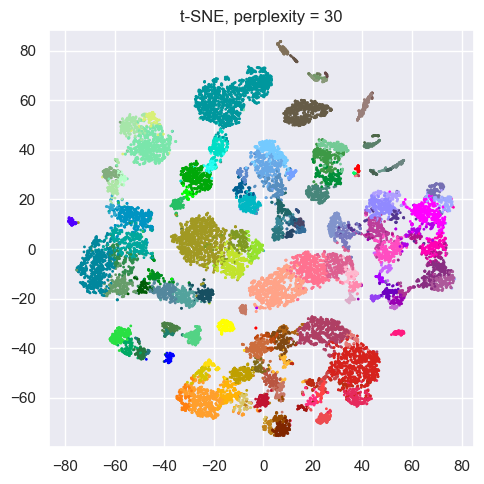

In [40]:
# This uses perplexity=30 (default) and random initialisation
# The result will depend on the random seed (here, 42)

%time tsne_default = fast_tsne(X, seed=42)  

plt.figure(figsize=(5,5))
plt.gca().set_aspect('equal', adjustable='datalim')
plt.scatter(tsne_default[:,0], tsne_default[:,1], s=1, 
            color=tasic2018['clusterColors'][tasic2018['clusters']])
plt.title('t-SNE, perplexity = 30')
plt.tight_layout()

## Our recommended t-SNE settings
Here we use scaled PCA as initialisation, learning rate n/12, and the combination of perplexities 30 and n/100.

=============== t-SNE v1.2.1 ===============
fast_tsne data_path: data_2026-09-19 23:00:56.378648-600105701.dat
fast_tsne result_path: result_2026-09-19 23:00:56.378648-600105701.dat
fast_tsne nthreads: 8
Read the following parameters:
	 n 23822 by d 50 dataset, theta 0.500000,
	 perplexity 0.000000, no_dims 2, max_iter 750,
	 stop_lying_iter 250, mom_switch_iter 250,
	 momentum 0.500000, final_momentum 0.800000,
	 learning_rate 1985.166667, max_step_norm 5.000000,
	 K -1, sigma -1.000000, nbody_algo 2,
	 knn_algo 1, early_exag_coeff 12.000000,
	 no_momentum_during_exag 0, n_trees 50, search_k 35700,
	 start_late_exag_iter -1, late_exag_coeff -1.000000
	 nterms 3, interval_per_integer 1.000000, min_num_intervals 50, t-dist df 1.000000
Read the 23822 x 50 data matrix successfully. X[0,0] = 31.364648
Read the list of perplexities: 30.000000 238.000000 
Read the initialization successfully.
Will use momentum during exaggeration phase
Computing input similarities...
Using perplexity, so no

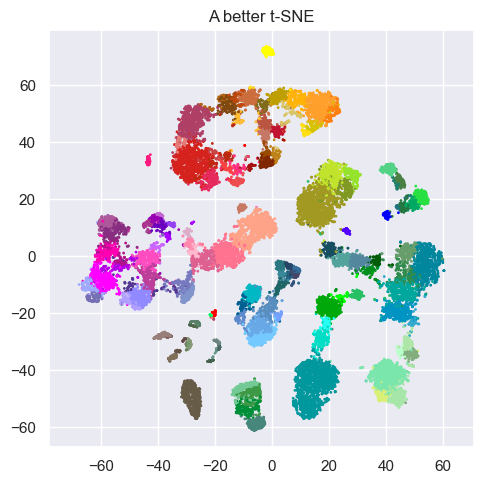

In [43]:
%%time

pcaInit = X[:,:2] / np.std(X[:,0]) * 0.0001
tsne_ours = fast_tsne(X, initialization = pcaInit,
                      learning_rate = X.shape[0]/12,
                      perplexity_list = [30, int(X.shape[0]/100)])

plt.figure(figsize=(5,5))
plt.gca().set_aspect('equal', adjustable='datalim')
plt.scatter(tsne_ours[:,0], tsne_ours[:,1], s=1,
            color=tasic2018['clusterColors'][tasic2018['clusters']])
plt.title('A better t-SNE')
plt.tight_layout()

## Comparing t-SNE to UMAP  

I also applied UMAP as a dimensionality reduction method, to compare it to t-SNE and the original PCA representation. 

### Questions
- How similar are the resulting embeddings?
- How does UMAP `n_neighbors` affect the embedding?
- Which aspects of local/global structure are preserved?

Output for these questions are in file [04_tsne_vs_umap.ipynb](https://github.com/PlantsGenesBugs/rna-seq-tsne-practice/blob/my-practice/04_tsne_vs_umap.ipynb).